In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


In [ ]:
import os

if os.path.exists("/kaggle/input"):
    BASE_PATH = "/kaggle/input/competitions/mlds-2026-assignment-2"
else:
    BASE_PATH = "../"

In [ ]:
#PART 1 ------------------- PCA

In [3]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

np.random.seed(23651)

**Pipeline:**
1. Load and flatten images → data matrix $X \in \mathbb{R}^{n \times p}$
2. Mean-centre → $\tilde{X} = X - \bar{x}$
3. Thin SVD: $\tilde{X} = U S V^\top$ — columns of $V$ are the principal components
4. Eigenvalues: $\lambda_k = s_k^2 / (n-1)$
5. Reconstruct, plot variance curve, sweep over $k$

In [ ]:
IMAGE_DIR = f"{BASE_PATH}/train/images"
IMG_SIZE = 32  

In [ ]:
# LOAD IMAGES
def load_images(image_dir, img_size=32):
    image_files = sorted(os.listdir(image_dir))
    images = []

    for fname in tqdm(image_files, desc='Loading images'):
        path = os.path.join(image_dir, fname)
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize((img_size, img_size), Image.BILINEAR)
            images.append(np.array(img, dtype=np.float64) / 255.0)
        except Exception:
            continue

    X = np.array(images).reshape(len(images), -1)
    print(f'Loaded {X.shape[0]} images  |  feature dim p = {X.shape[1]}')
    return X, image_files


X, image_files = load_images(IMAGE_DIR, IMG_SIZE)
n, p = X.shape
print(f'Data matrix X: {n} × {p}  (n_samples × n_features)')

Loading images: 100%|██████████| 2200/2200 [00:20<00:00, 105.81it/s]

Loaded 2200 images  |  feature dim p = 3072
Data matrix X: 2200 × 3072  (n_samples × n_features)


In [ ]:
# PCA via thin SVD

def compute_pca(X):
    # Step 1 — mean-centre
    mean       = X.mean(axis=0)          
    X_centered = X - mean                

    # Step 2 — SVD
    # X_centered = U S Vt
    print('Running thin SVD on the centred data matrix...')
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # Step 3 — principal components are the ROWS of Vt
    components  = Vt.T           
    # Step 4 — eigenvalues of the sample covariance matrix
    #   Cov = X_centered.T @ X_centered / (n-1)
    #   eigenvalue_k = s_k^2 / (n-1)
    eigenvalues = (S ** 2) / (n - 1)          

    print(f'PCA done  |  r = {len(S)} components  |  'f'top-3 eigenvalues: {eigenvalues[:3].round(5)}')
    return mean, components, eigenvalues


mean, components, eigenvalues = compute_pca(X)

Running thin SVD on the centred data matrix...
PCA done  |  r = 2200 components  |  top-3 eigenvalues: [47.48113 24.23125 10.3302 ]


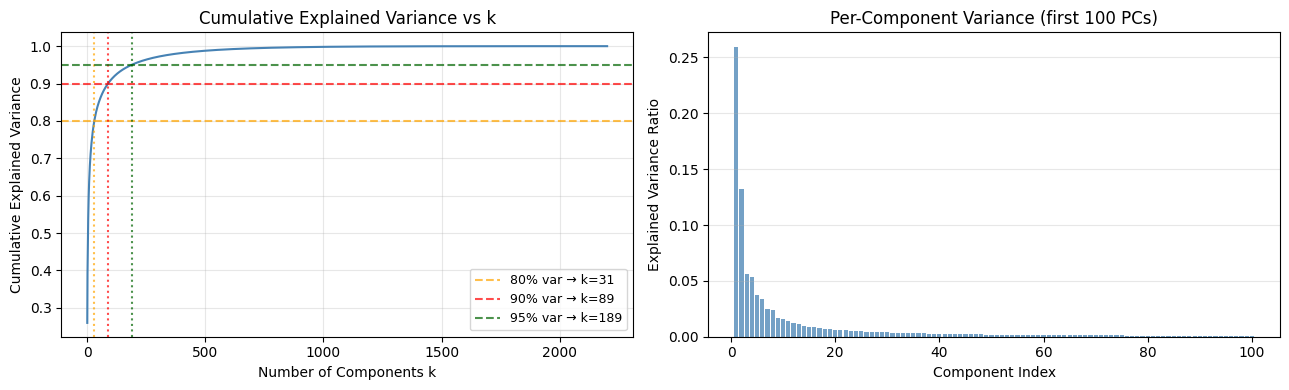

Saved: var_curve_pca.png
  80% variance explained by k = 31 components (out of 2200 total)
  90% variance explained by k = 89 components (out of 2200 total)
  95% variance explained by k = 189 components (out of 2200 total)
  99% variance explained by k = 552 components (out of 2200 total)


In [ ]:
# EXPLAINED VARIANCE and Find min k for threshold

def find_k_for_variance(eigenvalues, threshold=0.95):
    """
    Return the minimum number of principal components needed to
    explain at least `threshold` fraction of the total variance.
    """
    variance_ratio = eigenvalues / eigenvalues.sum()
    cumulative     = np.cumsum(variance_ratio)
    k = int(np.searchsorted(cumulative, threshold)) + 1
    return k, cumulative


def plot_variance(eigenvalues, k_marks=None):
    variance_ratio = eigenvalues / eigenvalues.sum()
    cumulative     = np.cumsum(variance_ratio)
    r              = len(eigenvalues)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.plot(range(1, r + 1), cumulative, linewidth=1.5, color='steelblue')
    for thresh, color in [(0.80, 'orange'), (0.90, 'red'), (0.95, 'darkgreen')]:
        k_t, _ = find_k_for_variance(eigenvalues, thresh)
        ax.axhline(thresh, linestyle='--', color=color, alpha=0.7,
                   label=f'{int(thresh*100)}% var → k={k_t}')
        ax.axvline(k_t,    linestyle=':', color=color,  alpha=0.7)
    ax.set_xlabel('Number of Components k')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title('Cumulative Explained Variance vs k')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    ax = axes[1]
    show = min(100, r)
    ax.bar(range(1, show + 1), variance_ratio[:show], color='steelblue', alpha=0.75)
    ax.set_xlabel('Component Index')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title(f'Per-Component Variance (first {show} PCs)')
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('var_curve_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: var_curve_pca.png')


plot_variance(eigenvalues)

for thresh in [0.80, 0.90, 0.95, 0.99]:
    k_t, _ = find_k_for_variance(eigenvalues, thresh)
    print(f'  {int(thresh*100)}% variance explained by k = {k_t} components '
          f'(out of {len(eigenvalues)} total)')

In [ ]:
#Projection and Reconstruction
def project(X, mean, components, k):
    W_k = components[:, :k]             
    return (X - mean) @ W_k           


def reconstruct(X, mean, components, k):
    W_k   = components[:, :k]          
    Z     = (X - mean) @ W_k            
    X_hat = Z @ W_k.T + mean         
    return X_hat


def reconstruction_mse(X, X_hat):
    return float(np.mean((X - X_hat) ** 2))

Computing reconstruction error:   0%|          | 0/11 [00:00<?, ?it/s]

  k=    2 | MSE=0.036195 | Variance retained=0.3920


Computing reconstruction error:  18%|█▊        | 2/11 [00:00<00:00, 10.57it/s]

  k=   10 | MSE=0.020582 | Variance retained=0.6543
  k=   50 | MSE=0.008921 | Variance retained=0.8501


Computing reconstruction error:  45%|████▌     | 5/11 [00:00<00:00,  9.07it/s]

...

  k= 1000 | MSE=0.000109 | Variance retained=0.9982


Computing reconstruction error:  91%|█████████ | 10/11 [00:01<00:00,  3.49it/s]

  k= 1500 | MSE=0.000014 | Variance retained=0.9998


Computing reconstruction error: 100%|██████████| 11/11 [00:02<00:00,  4.51it/s]

  k= 2000 | MSE=0.000001 | Variance retained=1.0000


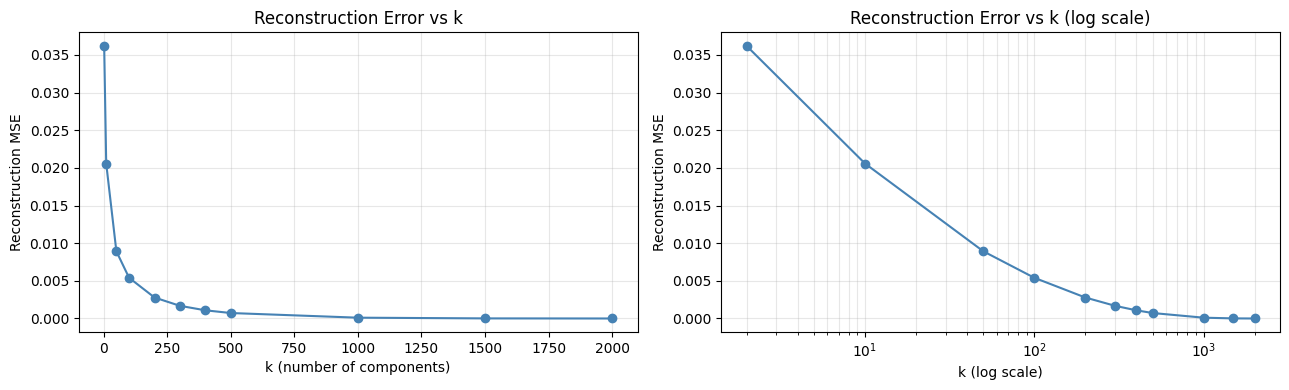

Saved: reconstruction_error.png


In [ ]:
#Plot recons error vs k
def plot_reconstruction_error(X, mean, components, k_values):
    errors = []
    for k in tqdm(k_values, desc='Computing reconstruction error'):
        X_hat = reconstruct(X, mean, components, k)
        mse   = reconstruction_mse(X, X_hat)
        errors.append(mse)
        var_ratio  = eigenvalues / eigenvalues.sum()
        var_kept   = np.cumsum(var_ratio)[k - 1]
        print(f'  k={k:5d} | MSE={mse:.6f} | Variance retained={var_kept:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(k_values, errors, marker='o', color='steelblue')
    axes[0].set_xlabel('k (number of components)')
    axes[0].set_ylabel('Reconstruction MSE')
    axes[0].set_title('Reconstruction Error vs k')
    axes[0].grid(alpha=0.3)

    axes[1].plot(k_values, errors, marker='o', color='steelblue')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('k (log scale)')
    axes[1].set_ylabel('Reconstruction MSE')
    axes[1].set_title('Reconstruction Error vs k (log scale)')
    axes[1].grid(alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('reconstruction_error.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: reconstruction_error.png')
    return errors


k_values = [2, 10, 50, 100, 200, 300, 400, 500, 1000, 1500, 2000]
errors   = plot_reconstruction_error(X, mean, components, k_values)

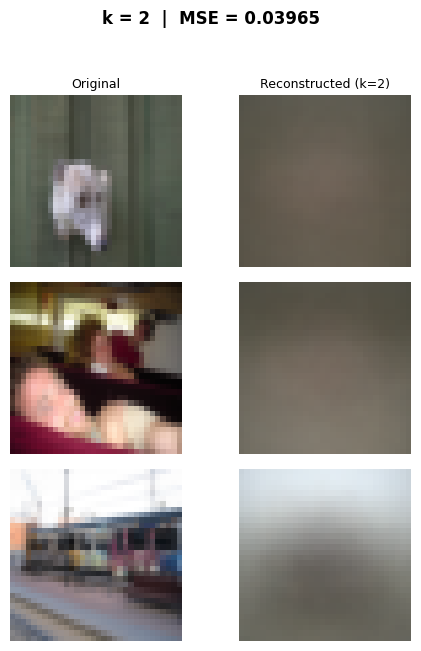

Saved: reconstruction_k2.png


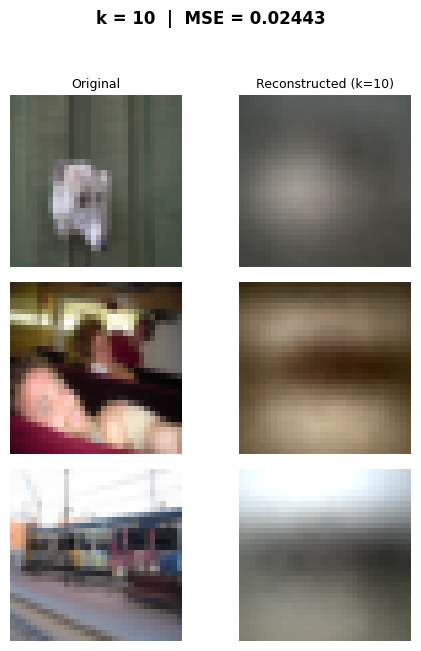

Saved: reconstruction_k10.png


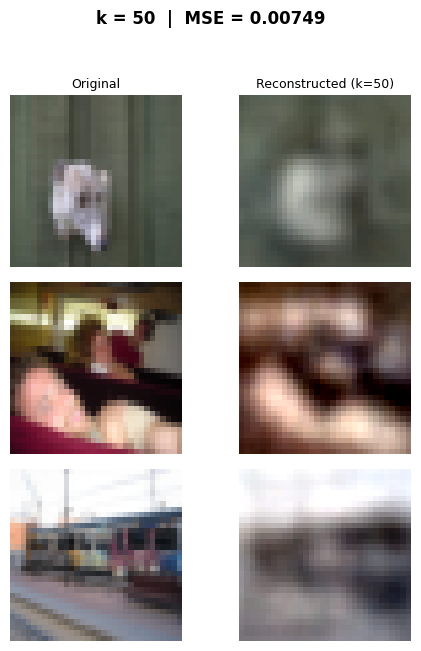

Saved: reconstruction_k50.png


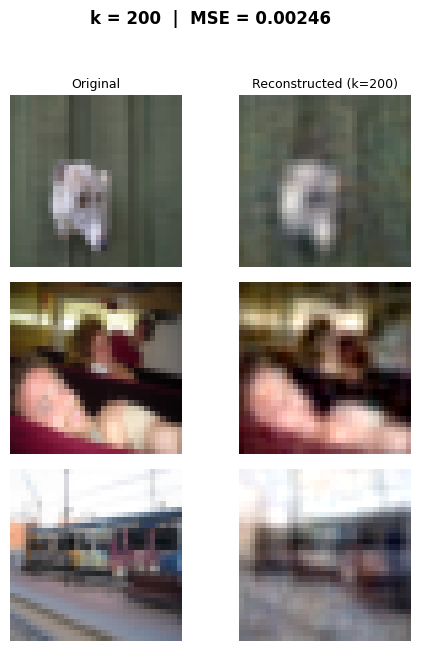

Saved: reconstruction_k200.png


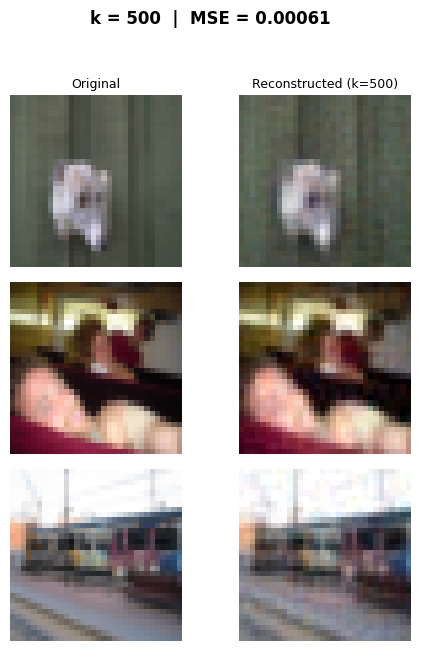

Saved: reconstruction_k500.png


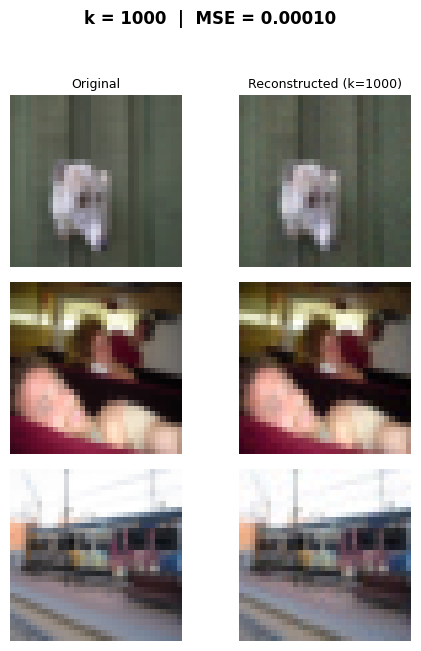

Saved: reconstruction_k1000.png


In [ ]:
#Visual Comparision: Og vs Recons
def show_reconstructions(X, mean, components, img_size, k_values_to_show,n_samples=3, start_idx=0):
    sample_X = X[start_idx : start_idx + n_samples]  

    for k in k_values_to_show:
        sample_hat = reconstruct(sample_X, mean, components, k)
        sample_mse = reconstruction_mse(sample_X, sample_hat)

        fig, axes = plt.subplots(n_samples, 2,
                                 figsize=(5, 2.2 * n_samples),
                                 squeeze=False)
        fig.suptitle(f'k = {k}  |  MSE = {sample_mse:.5f}', fontsize=12,
                     fontweight='bold')

        for row in range(n_samples):
            orig  = sample_X[row].reshape(img_size, img_size, 3)
            recon = np.clip(sample_hat[row].reshape(img_size, img_size, 3), 0, 1)

            axes[row, 0].imshow(orig)
            axes[row, 0].set_title('Original' if row == 0 else '', fontsize=9)
            axes[row, 0].axis('off')

            axes[row, 1].imshow(recon)
            axes[row, 1].set_title(f'Reconstructed (k={k})' if row == 0 else '', fontsize=9)
            axes[row, 1].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fname = f'reconstruction_k{k}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

k_show = [2, 10, 50, 200, 500, 1000]
show_reconstructions(X, mean, components, IMG_SIZE,k_values_to_show=k_show, n_samples=3, start_idx=0)

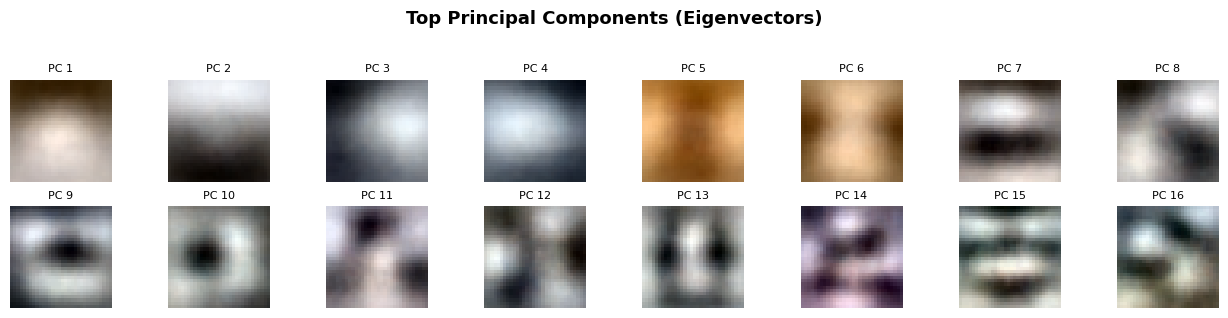

Saved: principal_components.png


In [ ]:
#Visualize top k principle cmponents
def plot_principal_components(components, img_size, n_show=16):
    n_cols = 8
    n_rows = int(np.ceil(n_show / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.6, n_rows * 1.6))
    fig.suptitle('Top Principal Components (Eigenvectors)', fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= n_show:
            ax.axis('off')
            continue
        pc = components[:, i].reshape(img_size, img_size, 3)
        # Normalise to [0,1] for display  (PCs can be negative)
        pc_norm = (pc - pc.min()) / (pc.max() - pc.min() + 1e-8)
        ax.imshow(pc_norm)
        ax.set_title(f'PC {i+1}', fontsize=8)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('principal_components.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: principal_components.png')
plot_principal_components(components, IMG_SIZE, n_show=16)

In [13]:
#PART 2---------------------- CLASSIFICATION AND SEGMENTATION

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

torch.manual_seed(23651)
np.random.seed(23651)

Device: cuda


In [2]:
os.makedirs('classification/weights', exist_ok=True)
os.makedirs('segmentation/weights',   exist_ok=True)
print('Directories ready:')
print('  classification/weights/')
print('  segmentation/weights/')

Directories ready:
  classification/weights/
  segmentation/weights/


In [3]:
#DATASET
CLASS_NAMES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

class MultiTaskDataset(Dataset):
    def __init__(self, image_dir, label_df, mask_dir=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.df        = label_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        image_id = row['image_id']

        img_path = os.path.join(self.image_dir, image_id + '.jpg')
        img      = cv2.imread(img_path)
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label = row[1:].values.astype(np.float32)

        mask = None
        if self.mask_dir:
            mask_path = os.path.join(self.mask_dir, image_id + '.png')
            mask = np.array(Image.open(mask_path))   # palette PNG → integer array

        if self.transform:
            if mask is not None:
                aug  = self.transform(image=img, mask=mask)
                img  = aug['image']
                mask = aug['mask']
            else:
                aug = self.transform(image=img)
                img = aug['image']

        if mask is not None:
            return img, torch.tensor(label), torch.tensor(mask).long()
        return img, torch.tensor(label)

In [4]:
# TRANSFORMS
IMG_SIZE = 320

train_transform = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.5, 1.0),
        interpolation=cv2.INTER_LINEAR
    ),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1, scale_limit=0.2, rotate_limit=15,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101, p=0.6
    ),
    A.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1, p=0.6
    ),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.CoarseDropout(
        max_holes=8, max_height=IMG_SIZE//10,
        max_width=IMG_SIZE//10, p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

In [ ]:
#Data Loading

label_df = pd.read_csv(os.path.join(BASE_PATH, 'train/labels.csv'))

train_size = int(0.85 * len(label_df))   # 85/15 split 
val_size   = len(label_df) - train_size

indices       = list(range(len(label_df)))
np.random.shuffle(indices)
train_indices = indices[:train_size]
val_indices   = indices[train_size:]

train_label_df = label_df.iloc[train_indices]
val_label_df   = label_df.iloc[val_indices]

train_dataset = MultiTaskDataset(
    image_dir = os.path.join(BASE_PATH, 'train/images'),
    label_df  = train_label_df,
    mask_dir  = os.path.join(BASE_PATH, 'train/segmentation_masks'),
    transform = train_transform
)

val_dataset = MultiTaskDataset(
    image_dir = os.path.join(BASE_PATH, 'train/images'),
    label_df  = val_label_df,
    mask_dir  = os.path.join(BASE_PATH, 'train/segmentation_masks'),
    transform = val_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

In [8]:
print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}')

Train: 1870  Val: 330


In [ ]:
#CLass Weights
def compute_pixel_counts(mask_dir, num_classes=21):
    counts = np.zeros(num_classes)
    for fname in tqdm(os.listdir(mask_dir), desc='Computing class weights'):
        mask = np.array(Image.open(os.path.join(mask_dir, fname)))
        mask = mask[mask != 255]
        for c in range(num_classes):
            counts[c] += (mask == c).sum()
    return counts

mask_dir   = os.path.join(BASE_PATH, 'train/segmentation_masks')
seg_counts = compute_pixel_counts(mask_dir, num_classes=21)
print('Pixel counts per class:', seg_counts)

def make_class_weights(counts, device):
    counts  = counts + 1e-6
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32).to(device)

seg_weights = make_class_weights(seg_counts,        device)   # 21 classes (incl bg)
cls_weights = make_class_weights(seg_counts[1:],    device)   # 20 classes (excl bg)

print('Seg weights:', seg_weights)
print('Cls weights:', cls_weights)

Computing class weights:   0%|          | 0/2200 [00:00<?, ?it/s]

Computing class weights: 100%|██████████| 2200/2200 [00:20<00:00, 106.86it/s]


Pixel counts per class: [2.73063579e+08 2.87047000e+06 1.09893000e+06 3.50385400e+06
 2.12711300e+06 2.66538800e+06 6.39539100e+06 4.85925900e+06
 9.58784600e+06 3.59421800e+06 3.52759700e+06 4.65217700e+06
 7.42174500e+06 3.77872900e+06 4.02895300e+06 1.98082470e+07
 2.33617800e+06 2.84932100e+06 5.46596000e+06 5.76241300e+06
 3.15253600e+06]
Seg weights: tensor([0.1223, 1.1928, 1.9278, 1.0796, 1.3857, 1.2379, 0.7991, 0.9168, 0.6527,
        1.0660, 1.0760, 0.9370, 0.7418, 1.0396, 1.0068, 0.4541, 1.3222, 1.1972,
        0.8644, 0.8419, 1.1382], device='cuda:0')
Cls weights: tensor([1.1427, 1.8468, 1.0343, 1.3274, 1.1858, 0.7655, 0.8782, 0.6252, 1.0212,
        1.0308, 0.8976, 0.7106, 0.9959, 0.9645, 0.4350, 1.2666, 1.1469, 0.8281,
        0.8065, 1.0904], device='cuda:0')


In [ ]:
#Classification 
from classification.model import (
    CLASS_NAMES, val_transform  as cls_val_transform,
    ClassificationBackbone,ClassificationModel,        
)

#Segmentation 
from segmentation.model import (
    val_transform  as seg_val_transform,
    conv_block,ASPP,                       
    SegmentationBackbone,SegmentationModel,         
)

print('Imported from classification/model.py:', ClassificationBackbone.__name__, ClassificationModel.__name__)
print('Imported from segmentation/model.py  :', SegmentationBackbone.__name__,  SegmentationModel.__name__)

Imported from classification/model.py: ClassificationBackbone ClassificationModel
Imported from segmentation/model.py  : SegmentationBackbone SegmentationModel


In [ ]:
# FOR TRAINING

cls_backbone = ClassificationBackbone(num_classes=20).to(device)
print('Classification backbone parameters:',sum(p.numel() for p in cls_backbone.parameters() if p.requires_grad))


Classification backbone parameters: 28241492


In [ ]:
#FOR TRAINING
seg_backbone = SegmentationBackbone(num_classes=21).to(device)
print('Segmentation backbone parameters:',sum(p.numel() for p in seg_backbone.parameters() if p.requires_grad))


Segmentation backbone parameters: 44281877


In [ ]:
#LOSS FUNCTIONS
criterion_cls = nn.BCEWithLogitsLoss(pos_weight=cls_weights)
criterion_ce  = nn.CrossEntropyLoss(weight=seg_weights,ignore_index=255) 

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        preds   = torch.softmax(logits, dim=1)
        valid   = targets != 255
        t_clean = targets.clone(); t_clean[~valid] = 0
        t_oh    = F.one_hot(t_clean, num_classes=logits.shape[1]).permute(0,3,1,2).float()
        mask    = valid.unsqueeze(1).float()
        preds   = preds * mask; t_oh = t_oh * mask
        inter   = (preds * t_oh).sum(dim=(2,3))
        denom   = preds.sum(dim=(2,3)) + t_oh.sum(dim=(2,3))
        return 1 - ((2 * inter + self.smooth) / (denom + self.smooth)).mean()

criterion_dice = DiceLoss()
print('Loss functions ready.')

Loss functions ready.


In [18]:
def plot_metric(epochs, metric, label, ylabel, title, fig_name):
    plt.figure(); plt.plot(epochs, metric, label=label)
    plt.legend(); plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.title(title)
    plt.tight_layout(); plt.savefig(fig_name); plt.show()


In [19]:
# Classfication- Training and Evaluation
scaler_cls = GradScaler()

def train_cls_epoch(model, loader, optimizer):
    model.train(); total_loss = 0.0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            loss = criterion_cls(model(imgs), labels)
        scaler_cls.scale(loss).backward()
        scaler_cls.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_cls.step(optimizer); scaler_cls.update()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_f1(model, loader, thresholds=None):
    if thresholds is None: thresholds = np.full(20, 0.5)
    model.eval(); all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            probs = torch.sigmoid(model(imgs.to(device))).cpu().numpy()
            all_probs.append(probs); all_labels.append(labels.numpy())
    probs  = np.vstack(all_probs); labels = np.vstack(all_labels)
    preds  = (probs > thresholds).astype(int)
    return f1_score(labels, preds, average='samples', zero_division=0), probs, labels

def tune_per_class_thresholds(probs, labels, grid=np.arange(0.2, 0.75, 0.05)):
    best_thresholds = np.full(probs.shape[1], 0.5)
    for c in range(probs.shape[1]):
        best_f1, best_t = 0.0, 0.5
        for t in grid:
            preds_c = (probs[:, c] > t).astype(int)
            if preds_c.sum() == 0: continue
            f1_c = f1_score(labels[:, c], preds_c, zero_division=0)
            if f1_c > best_f1: best_f1, best_t = f1_c, t
        best_thresholds[c] = best_t
    return best_thresholds


In [ ]:
CLS_EPOCHS = 80
CLS_LR     = 3e-4

cls_backbone  = ClassificationBackbone(num_classes=20).to(device)
optimizer_cls = torch.optim.AdamW(cls_backbone.parameters(), lr=CLS_LR, weight_decay=1e-4)
scheduler_cls = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cls, T_max=CLS_EPOCHS, eta_min=1e-6)

best_cls_f1       = 0.0
cls_train_losses  = []
cls_val_f1s       = []
cls_lrs           = []

for epoch in range(CLS_EPOCHS):
    loss = train_cls_epoch(cls_backbone, train_loader, optimizer_cls)
    scheduler_cls.step()
    cls_train_losses.append(loss)

    f1, val_probs, val_labels = evaluate_f1(cls_backbone, val_loader)
    lr_now = scheduler_cls.get_last_lr()[0]
    cls_val_f1s.append(f1); cls_lrs.append(lr_now)
    print(f'Epoch {epoch+1:3d}/{CLS_EPOCHS}  Loss: {loss:.4f}  F1: {f1:.4f}  LR: {lr_now:.2e}')

    if f1 > best_cls_f1:
        best_cls_f1 = f1
        torch.save(cls_backbone.state_dict(), 'classification/weights/best_cls_model.pth')
        print('  ✅ Saved to classification/weights/best_cls_model.pth')

print(f'\nBest Val F1: {best_cls_f1:.4f}')


Epoch   1/80  Loss: 0.2749  F1: 0.3281  LR: 3.00e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   2/80  Loss: 0.1873  F1: 0.3845  LR: 3.00e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   3/80  Loss: 0.1801  F1: 0.4852  LR: 2.99e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   4/80  Loss: 0.1694  F1: 0.5357  LR: 2.98e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   5/80  Loss: 0.1619  F1: 0.5324  LR: 2.97e-04
Epoch   6/80  Loss: 0.1572  F1: 0.5652  LR: 2.96e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   7/80  Loss: 0.1483  F1: 0.5537  LR: 2.94e-04
Epoch   8/80  Loss: 0.1459  F1: 0.6180  LR: 2.93e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch   9/80  Loss: 0.1421  F1: 0.6159  LR: 2.91e-04
Epoch  10/80  Loss: 0.1383  F1: 0.6079  LR: 2.89e-04
Epoch  11/80  Loss: 0.1316  F1: 0.6408  LR: 2.86e-04
  ✅ Saved → classification/weights/best_cls_model.pth
Epoch  12/80  Loss: 0.1315  F1: 0.6140 

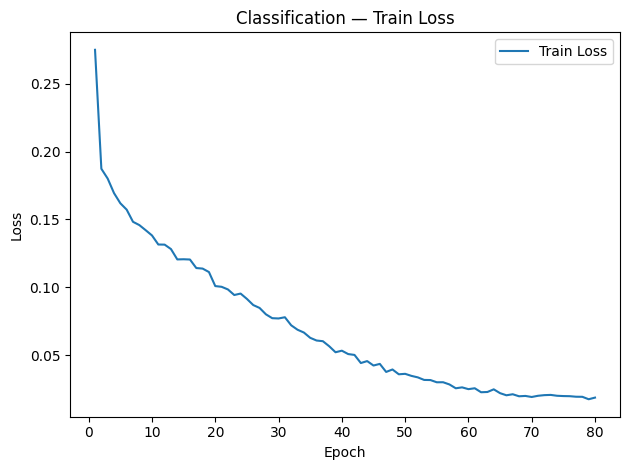

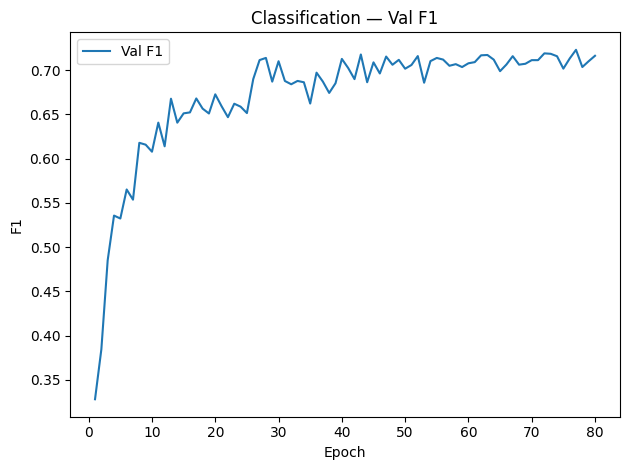

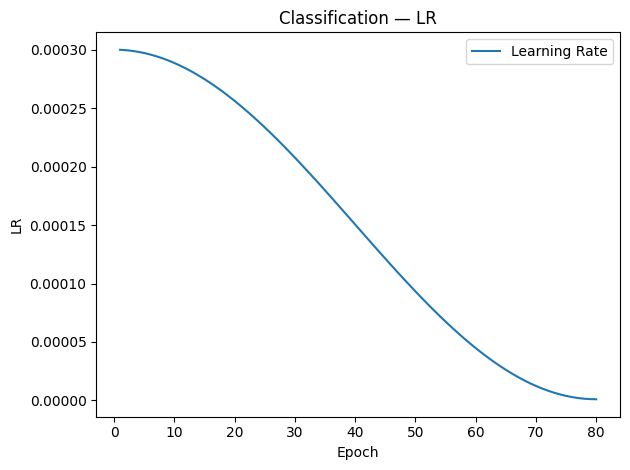

In [ ]:
epochs = range(1, CLS_EPOCHS + 1)
plot_metric(epochs, cls_train_losses,'Train Loss','Loss','Classification — Train Loss','cls_train_loss.png')
plot_metric(epochs, cls_val_f1s, 'Val F1','F1','Classification — Val F1','cls_val_f1.png')
plot_metric(epochs, cls_lrs,'Learning Rate', 'LR','Classification — LR','cls_lr.png')


In [ ]:
#THRESHOLD TUNING
cls_backbone.load_state_dict(torch.load('classification/weights/best_cls_model.pth'))
_, val_probs, val_labels = evaluate_f1(cls_backbone, val_loader)

best_thresholds = tune_per_class_thresholds(val_probs, val_labels)
print('Per-class thresholds:', dict(zip(CLASS_NAMES, best_thresholds.round(2))))

f1_tuned, _, _ = evaluate_f1(cls_backbone, val_loader, thresholds=best_thresholds)
print(f'F1 with tuned thresholds: {f1_tuned:.4f}')

np.save('classification/weights/best_thresholds.npy', best_thresholds)
print('Saved: classification/weights/best_thresholds.npy')


In [17]:
#Segmentation- Training and Evaluation
scaler_seg = GradScaler()

def train_seg_epoch(model, loader, optimizer, dice_w=0.4):
    model.train(); total_loss = 0.0
    for imgs, _, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            out  = model(imgs)
            loss = criterion_ce(out, masks) + dice_w * criterion_dice(out, masks)
        scaler_seg.scale(loss).backward()
        scaler_seg.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_seg.step(optimizer); scaler_seg.update()
        total_loss += loss.item()
    return total_loss / len(loader)

def compute_miou(pred, target, num_classes=21):
    ious = []
    valid = target != 255
    for cls in range(1, num_classes):
        pm = (pred == cls)[valid]; tm = (target == cls)[valid]
        if tm.sum() == 0: continue
        inter = (pm & tm).sum(); union = (pm | tm).sum()
        if union > 0: ious.append(inter / union)
    return float(np.mean(ious)) if ious else 1.0

def evaluate_miou(model, loader):
    model.eval(); scores = []
    with torch.no_grad():
        for imgs, _, masks in loader:
            with autocast():
                out = model(imgs.to(device))
            preds = torch.argmax(out, dim=1).cpu().numpy()
            for p, t in zip(preds, masks.numpy()):
                scores.append(compute_miou(p, t))
    return scores


In [ ]:
# SEGMENTATION MODEL A
SEG_EPOCHS = 100
SEG_LR     = 3e-5
DICE_W     = 0.5

seg_backbone  = SegmentationBackbone(num_classes=21).to(device)
optimizer_seg = torch.optim.AdamW(seg_backbone.parameters(), lr=SEG_LR, weight_decay=1e-4)
scheduler_seg = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_seg, T_max=SEG_EPOCHS, eta_min=1e-6)

best_seg_miou      = 0.0
seg_A_train_losses = []
seg_A_val_miou     = []
seg_A_lrs          = []

for epoch in range(1, SEG_EPOCHS + 1):
    loss   = train_seg_epoch(seg_backbone, train_loader, optimizer_seg, dice_w=DICE_W)
    scheduler_seg.step()
    seg_A_train_losses.append(loss)

    miou   = np.mean(evaluate_miou(seg_backbone, val_loader))
    lr_now = scheduler_seg.get_last_lr()[0]
    seg_A_val_miou.append(miou); seg_A_lrs.append(lr_now)
    print(f'Epoch {epoch:3d}/{SEG_EPOCHS}  Loss: {loss:.4f}  mIoU: {miou:.4f}  LR: {lr_now:.2e}')

    if miou > best_seg_miou:
        best_seg_miou = miou
        # ── Save to submission-compliant location ──
        torch.save(seg_backbone.state_dict(), 'segmentation/weights/best_seg_model_A.pth')
        print('  ✅ Saved to segmentation/weights/best_seg_model_A.pth')

print(f'\nBest Val mIoU (A): {best_seg_miou:.4f}')


Epoch   1/100  Loss: 3.4382  mIoU: 0.1602  LR: 3.00e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   2/100  Loss: 3.1195  mIoU: 0.1887  LR: 3.00e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   3/100  Loss: 2.9286  mIoU: 0.2341  LR: 2.99e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   4/100  Loss: 2.7812  mIoU: 0.2744  LR: 2.99e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   5/100  Loss: 2.6238  mIoU: 0.2984  LR: 2.98e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   6/100  Loss: 2.5107  mIoU: 0.3297  LR: 2.97e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   7/100  Loss: 2.4416  mIoU: 0.4070  LR: 2.97e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   8/100  Loss: 2.3118  mIoU: 0.4638  LR: 2.95e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch   9/100  Loss: 2.2165  mIoU: 0.4668  LR: 2.94e-05
  ✅ Saved → segmentation/weights/best_seg_model_A.pth
Epoch  10/

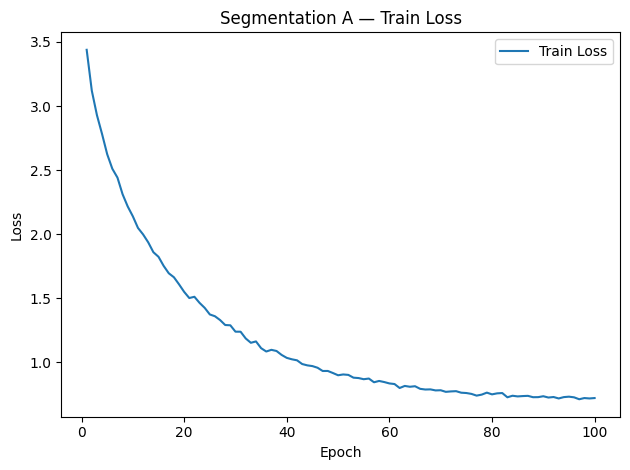

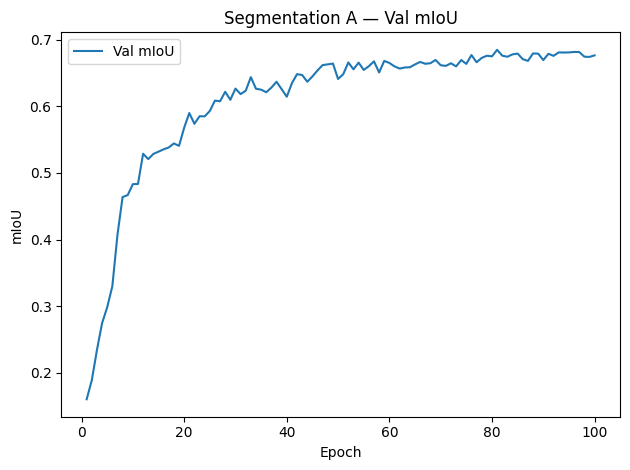

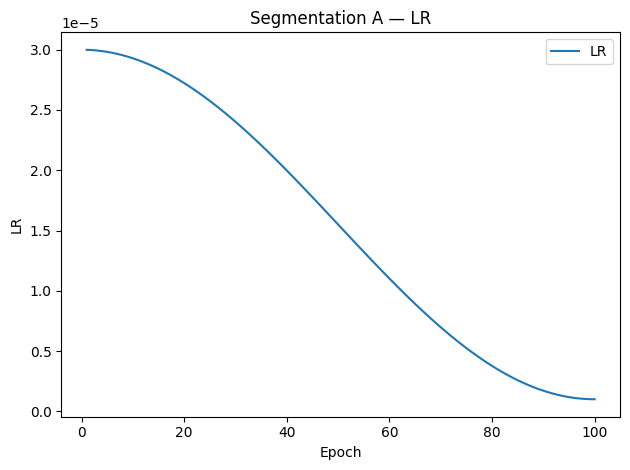

In [ ]:
seg_epochs = range(1, SEG_EPOCHS + 1)
plot_metric(seg_epochs, seg_A_train_losses, 'Train Loss', 'Loss',  'Segmentation A — Train Loss', 'seg_A_train_loss.png')
plot_metric(seg_epochs, seg_A_val_miou,'Val mIoU','mIoU','Segmentation A — Val mIoU','seg_A_val_miou.png')
plot_metric(seg_epochs, seg_A_lrs,'LR','LR','Segmentation A — LR','seg_A_lr.png')


In [ ]:
# SEGMENTATION -------- Model B (for Wilcoxon test)
SEG_EPOCHS_B = 100
SEG_LR_B     = 1e-4
DICE_W_B     = 0.6

seg_backbone_B  = SegmentationBackbone(num_classes=21).to(device)
optimizer_seg_B = torch.optim.AdamW(seg_backbone_B.parameters(), lr=SEG_LR_B, weight_decay=1e-4)
scheduler_seg_B = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_seg_B, T_max=SEG_EPOCHS_B, eta_min=1e-6)

best_seg_miou_B    = 0.0
seg_B_train_losses = []
seg_B_val_miou     = []
seg_B_lrs          = []

for epoch in range(1, SEG_EPOCHS_B + 1):
    loss   = train_seg_epoch(seg_backbone_B, train_loader, optimizer_seg_B, dice_w=DICE_W_B)
    scheduler_seg_B.step()
    seg_B_train_losses.append(loss)

    miou   = np.mean(evaluate_miou(seg_backbone_B, val_loader))
    lr_now = scheduler_seg_B.get_last_lr()[0]
    seg_B_val_miou.append(miou); seg_B_lrs.append(lr_now)
    print(f'Epoch {epoch:3d}/{SEG_EPOCHS_B}  Loss: {loss:.4f}  mIoU: {miou:.4f}  LR: {lr_now:.2e}')

    if miou > best_seg_miou_B:
        best_seg_miou_B = miou
        torch.save(seg_backbone_B.state_dict(), 'segmentation/weights/best_seg_model_B.pth')
        print('  ✅ Saved to segmentation/weights/best_seg_model_B.pth')

print(f'\nBest Val mIoU (B): {best_seg_miou_B:.4f}')

Epoch   1/100  Loss: 3.3079  mIoU: 0.1592  LR: 1.00e-04
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   2/100  Loss: 2.9310  mIoU: 0.2538  LR: 9.99e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   3/100  Loss: 2.7210  mIoU: 0.2998  LR: 9.98e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   4/100  Loss: 2.5781  mIoU: 0.3191  LR: 9.96e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   5/100  Loss: 2.4621  mIoU: 0.2820  LR: 9.94e-05
Epoch   6/100  Loss: 2.3626  mIoU: 0.3786  LR: 9.91e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   7/100  Loss: 2.2755  mIoU: 0.3997  LR: 9.88e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   8/100  Loss: 2.1935  mIoU: 0.4192  LR: 9.84e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch   9/100  Loss: 2.1164  mIoU: 0.4087  LR: 9.80e-05
Epoch  10/100  Loss: 2.0404  mIoU: 0.4360  LR: 9.76e-05
  ✅ Saved → segmentation/weights/best_seg_model_B.pth
Epoch  1

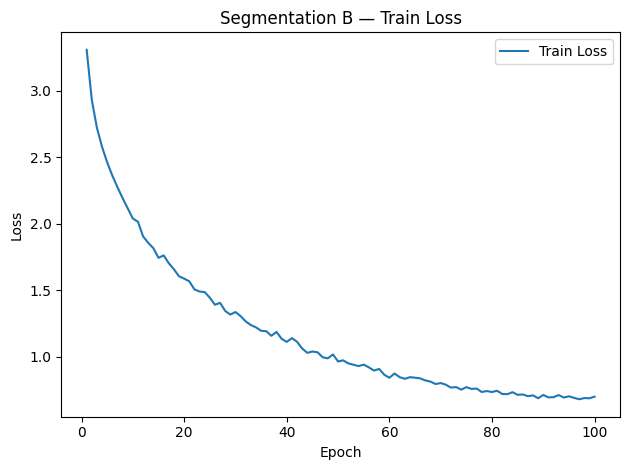

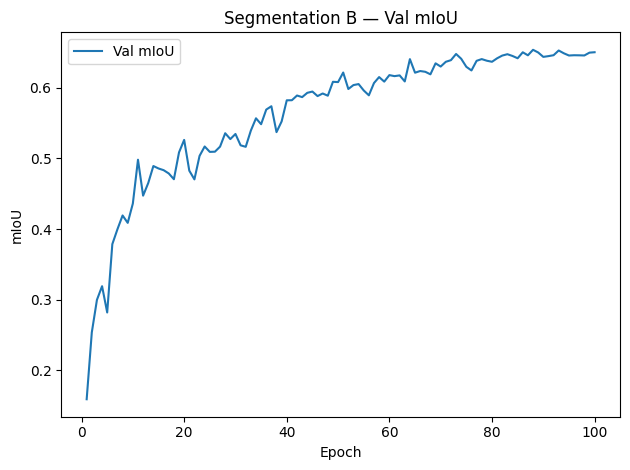

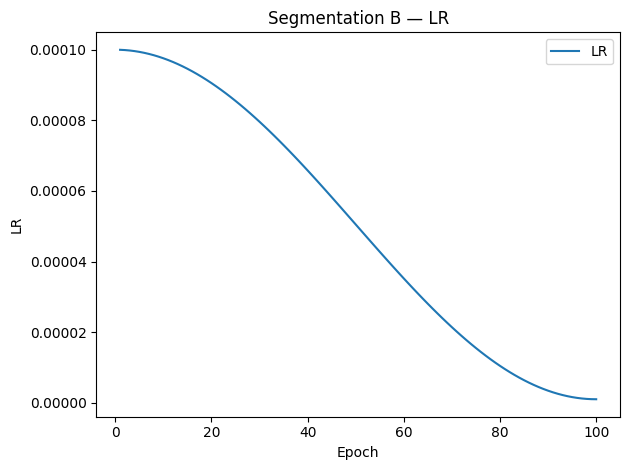

In [ ]:
seg_epochs_B = range(1, SEG_EPOCHS_B + 1)
plot_metric(seg_epochs_B,seg_B_train_losses,'Train Loss', 'Loss','Segmentation B — Train Loss','seg_B_train_loss.png')
plot_metric(seg_epochs_B, seg_B_val_miou,'Val mIoU','mIoU','Segmentation B — Val mIoU','seg_B_val_miou.png')
plot_metric(seg_epochs_B, seg_B_lrs,'LR','LR','Segmentation B — LR','seg_B_lr.png')


In [ ]:
def mask_to_rle(mask: np.ndarray) -> str:
    flat  = mask.flatten()
    parts = []
    i     = 0
    while i < len(flat):
        if flat[i] != 0:
            start, val = i, int(flat[i])
            while i < len(flat) and flat[i] == val:
                i += 1
            parts.extend([str(start), str(i - start), str(val)])
        else:
            i += 1
    return ' '.join(parts) if parts else '0 0 0'

def rle_to_mask(rle_string: str, height: int, width: int) -> np.ndarray:
    mask  = np.zeros(height * width, dtype=np.uint8)
    parts = list(map(int, rle_string.split()))
    for i in range(0, len(parts), 3):
        s, l, v = parts[i], parts[i+1], parts[i+2]
        mask[s:s+l] = v
    return mask.reshape(height, width)


In [ ]:
#RESULTS
cls_model = ClassificationModel(weights_dir='classification/weights')
seg_model = SegmentationModel(weights_dir='segmentation/weights')

best_thresholds = np.load('classification/weights/best_thresholds.npy')

TEST_DIR = os.path.join(BASE_PATH, 'test/images')
results  = []

for fname in tqdm(sorted(os.listdir(TEST_DIR)), desc='Generating predictions'):
    img_rgb  = cv2.cvtColor(cv2.imread(os.path.join(TEST_DIR, fname)), cv2.COLOR_BGR2RGB)
    image_id = os.path.splitext(fname)[0]

    # Classification
    prob_dict = cls_model.predict(img_rgb)                          
    probs     = np.array([prob_dict[n] for n in CLASS_NAMES])
    pred_cls  = [CLASS_NAMES[i] for i in np.where(probs > best_thresholds)[0]]
    cls_str   = ' '.join(pred_cls) if pred_cls else 'background'

    #Segmentation
    mask = seg_model.predict(img_rgb)                              
    rle  = mask_to_rle(mask)

    results.append([image_id, cls_str, rle])

submission = pd.DataFrame(results, columns=['image_id', 'classification', 'segmentation_rle'])
submission.to_csv('submission.csv', index=False)
print('Saved: submission.csv')
print(submission.head())

Generating predictions: 100%|██████████| 713/713 [01:21<00:00,  8.75it/s]


Saved: submission.csv
    image_id    classification  \
0  img_00005    bicycle person   
1  img_00009      chair person   
2  img_00010  motorbike person   
3  img_00014               cat   
4  img_00015      horse person   

                                    segmentation_rle  
0  67710 6 15 67718 1 15 68204 18 15 68704 18 15 ...  
1  45604 3 13 46100 11 13 46600 16 13 47100 21 13...  
2  65265 10 14 65761 16 14 66257 25 14 66755 28 1...  
3  26763 64 8 27246 90 8 27738 106 8 28232 115 8 ...  
4  30365 12 15 30679 18 15 30997 18 15 31314 21 1...  
